In [2]:
import os
import avstack
import avapi
import cv2  
import ipywidgets as wg
from IPython.display import SVG
from IPython.display import Video
from IPython.display import display
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Importing data
data_base = '../../data'
obj_data_dir_k = os.path.join(data_base, 'KITTI/object')
raw_data_dir_k = os.path.join(data_base, 'KITTI/raw') 
data_dir_n     = os.path.join(data_base, 'nuScenes')
data_dir_c     = os.path.join(data_base, 'CARLA/ego-lidar')

# Instantiating Scene Manager
KSM = avapi.kitti.KittiScenesManager(obj_data_dir_k, raw_data_dir_k, convert_raw=False)
NSM = avapi.nuscenes.nuScenesManager(data_dir_n)
CSM = avapi.carla.CarlaScenesManager(data_dir_c)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def make_movie_from_DM(DM, dataset_name, save=False, show_in_notebook=True):
        
    if DM.frames is None:
        print("NO FRAMES IN SCENE")
        return 
        
    range_frames = range(len(DM.frames))
    CAM = 'image-2'
    if (dataset_name == 'carla'):
        range_frames = range(4, len(DM.frames)-5)
        CAM = 'CAM_FRONT'
    if (dataset_name == 'nuscenes'):
        CAM = 'main_camera'        
        
    imgs = []
    boxes = []
    for frame_idx in range_frames:
        frame = DM.get_frames(sensor="main_camera")[frame_idx]
        img_boxes = DM.get_objects(frame, sensor="main_lidar") # using ground truth
        img = DM.get_image(frame, sensor=CAM)
        
        boxes.append(img_boxes)
        imgs.append(img)

    make_movie(imgs, boxes, fps=DM.framerate, name=dataset_name, save=save, show_in_notebook=show_in_notebook)

def make_movie(raw_imgs, boxes, fps=10, name="untitled", save=False, show_in_notebook=True):
    
    # process images (adding boxes to raw images)
    processed_imgs = []
    for img, box in zip(raw_imgs, boxes):
        processed_imgs.append(avapi.visualize.snapshot.show_image_with_boxes(img, box, inline=False, return_images=True))
    
    height, width, layers = processed_imgs[0].shape
    size = (width,height)
    # generate movie
    if save:
        movie_name = name + '_scene_movie.mp4'
    
        video = cv2.VideoWriter(movie_name,cv2.VideoWriter_fourcc(*'DIVX'), fps, size)
        for img in processed_imgs:
            video.write(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        
        # Deallocating memories taken for window creation 
        cv2.destroyAllWindows()  
        print("Scene video saved sucessfully")

        video.release()  # releasing the video generated 
    
    # show in notebook
    if show_in_notebook:
        make_slider_view(processed_imgs)
        
def make_slider_view(imgs):
    
    def f(idx):
        axs_slider.imshow(imgs[idx])
        axs_slider.set_title("Frame %03i" % int(idx))
        fig.canvas.draw()
        display(fig)
        
    # make slider view
    fig, axs_slider = plt.subplots(1,1)
    plt.axis('off')
    wg.interact(f,idx=wg.IntSlider(min=0, max=len(imgs) - 1, step=1, value=0))
   

In [5]:
# Instantiating Data Managers
KDM = KSM.get_scene_dataset_by_index(scene_idx=0)
CDM = CSM.get_scene_dataset_by_index(scene_idx=0)
NDM = NSM.get_scene_dataset_by_index(scene_idx=0)
    
# Testing
make_movie_from_DM(NDM, 'nuscenes', save=True)
# avapi.visualize.movie.make_movie_from_DM(NDM, 'nuscenes', save=True)


AttributeError: module 'avapi.visualize' has no attribute 'movie'

In [22]:
def make_movie(DM, dataset_name, save_movie=False):
   
    model = '2d-img'
    if (dataset_name == 'nuscenes'):
       model = '3d-lidar'
       
    # if model == '2d-img':
    #     M = avstack.modules.perception.object2dfv.MMDetObjectDetector2D(
    #         model='fasterrcnn', dataset=dataset_name, gpu=1)
    # elif model == '3d-img':
    #     M = avstack.modules.perception.object3d.MMDetObjectDetector3D(
    #         model='pgd', dataset=dataset_name, gpu=0)
    # elif model == '3d-lidar':
    #     M = avstack.modules.perception.object3d.MMDetObjectDetector3D(
    #         model='pointpillars', dataset=dataset_name, gpu=1)
    # else:
    #     raise NotImplementedError(model)
    
    if DM.frames is None:
        print("NO FRAMES in Scene")
        return 
        
    range_frames = range(len(DM.frames))
    CAM = 'image-2'
    if (dataset_name == 'carla'):
        range_frames = range(4, len(DM.frames)-5)
        CAM = 'CAM_FRONT'
    if (dataset_name == 'nuscenes'):
        CAM = 'main_camera'        
        
    imgs = []
    for frame_idx in range_frames:
        frame = DM.get_frames(sensor="main_camera")[frame_idx]
        objects = DM.get_objects(frame, sensor='main_lidar')
        img = DM.get_image(frame, sensor=CAM)
        pc = DM.get_lidar(frame)
        # ts = DM.get_timestamp(frame=frame, sensor=CAM)
        # if model == '2d-img':
        #     outputs = M(img, identifier='test', frame=frame)
        # elif model == '3d-img':
        #     outputs = M(img, identifier='test', frame=frame)
        # elif model == '3d-lidar':
        #     outputs = M(pc, identifier='test', frame=frame)
        # else:
        #     raise NotImplementedError(model)

        # if using perception:
        # boxes = outputs.data

        # if using ground truth
        boxes = objects
        
        imgs.append(avapi.visualize.snapshot.show_image_with_boxes(img, boxes, inline=False, return_images=True))

    # generate movie
    movie_name = dataset_name + '_scene_movie.mp4'
  
    height, width, layers = imgs[0].shape
    size = (width,height)
    fps = DM.framerate
    video = cv2.VideoWriter(movie_name,cv2.VideoWriter_fourcc(*'DIVX'), fps, size)
    for img in imgs:
        video.write(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    
    # Deallocating memories taken for window creation 
    cv2.destroyAllWindows()  
    print("Scene video:")
    
    video.release()  # releasing the video generated 

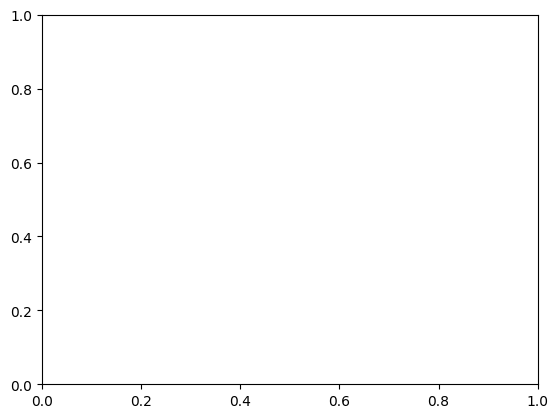

interactive(children=(IntSlider(value=1, description='x', max=4, min=1), Output()), _dom_classes=('widget-inte…

In [17]:
import ipywidgets as wg
from IPython.display import SVG

import matplotlib.pyplot as plt

# use this as inspiration
# https://github.com/avstack-lab/lib-avstack-api/blob/main/avapi/visualize/replay.py

fig, ax = plt.subplots(1,1)

def f(x):
    fname = '/data/shared/KITTI/object/2011_09_26_drive_0001_sync-experiment/image_2/%06d.png' % int(x)
    img = cv2.imread(fname)
    ax.imshow(img)
    fig.canvas.draw()

wg.interact(f, x=wg.IntSlider(min=1,max=4,step=1));